<a href="https://colab.research.google.com/github/jshin1023/calorie-prediction-model/blob/main/Calorie_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#model that predicts calorie expenditure based on heartrate, steps, MET value, intensity, and individual weight (time series analysis)
#https://www.kaggle.com/datasets/arashnic/fitbit/data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/fitbit")

print("Path to dataset files:", path)

100%|██████████| 43.3M/43.3M [00:00<00:00, 205MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2')

['mturkfitbit_export_3.12.16-4.11.16', 'mturkfitbit_export_4.12.16-5.12.16']

In [ ]:
os.listdir('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16')

['minuteSleep_merged.csv',
 'heartrate_seconds_merged.csv',
 'minuteStepsNarrow_merged.csv',
 'minuteMETsNarrow_merged.csv',
 'weightLogInfo_merged.csv',
 'hourlyIntensities_merged.csv',
 'hourlyCalories_merged.csv',
 'dailyActivity_merged.csv',
 'minuteIntensitiesNarrow_merged.csv',
 'minuteCaloriesNarrow_merged.csv',
 'hourlySteps_merged.csv']

In [ ]:
#load the datasets needed for model
calories = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv')
hr = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv')
steps = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteStepsNarrow_merged.csv')
mets = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv')
intensity = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteIntensitiesNarrow_merged.csv')
weight = pd.read_csv('/root/.cache/kagglehub/datasets/arashnic/fitbit/versions/2/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv')

In [ ]:
#explicitly define time format since it takes to long to convert timestamps from dataframe to date time
files = [calories, steps, mets, intensity]
for df in files:
    df['ActivityMinute'] = pd.to_datetime(df['ActivityMinute'],
                                          format='%m/%d/%Y %I:%M:%S %p')

In [ ]:
#different for heartrate since it measures in seconds
hr['Time'] = pd.to_datetime(hr['Time'], format='%m/%d/%Y %I:%M:%S %p')

In [ ]:
#convert hearrate to average minutes since it is in seconds
hr_min = hr.groupby(['Id', pd.Grouper(key='Time', freq='1Min')])['Value'].mean().reset_index()
hr_min.rename(columns={'Value': 'HeartRate', 'Time': 'ActivityMinute'}, inplace=True)

In [ ]:
#merge dataframes on id and minute
data = calories.merge(steps, on=['Id', 'ActivityMinute'], how='inner')
data = data.merge(intensity, on=['Id', 'ActivityMinute'], how='inner')
data = data.merge(mets, on=['Id', 'ActivityMinute'], how='inner')
data = data.merge(hr_min, on=['Id', 'ActivityMinute'], how='left')

In [ ]:
weight_avg = weight.groupby('Id')['WeightKg'].mean().reset_index()
data = data.merge(weight_avg, on='Id', how='left')

In [ ]:
#fill in missing heartrate data
data['HeartRate'] = data['HeartRate'].interpolate().fillna(method='bfill')

/tmp/ipython-input-4041306161.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['HeartRate'] = data['HeartRate'].interpolate().fillna(method='bfill')


In [ ]:
#temproal features: features that describe when something happens: help model learn patterns that depend on time
data['hour'] = data['ActivityMinute'].dt.hour
data['dayofweek'] = data['ActivityMinute'].dt.dayofweek
data['is_weekend'] = data['dayofweek'].isin([5,6]).astype(int)

#rolling features: features that summarize recent history of a signal (short trends or variability)
#why important?: calories bruns from recent intensity as well, they model lag effects (calories burn after exercise)
data['hr_roll_mean_5'] = data.groupby('Id')['HeartRate'].transform(lambda x: x.rolling(5, 1).mean())
data['steps_roll_sum_5'] = data.groupby('Id')['Steps'].transform(lambda x: x.rolling(5, 1).sum())

In [ ]:
#training/testing the model (shrunk the number of estimators from 200 to 50, and set a max tree depth to 10 since it took too long to run)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Drop NaNs
model_data = data.dropna(subset=['Calories', 'HeartRate'])

X = model_data[['HeartRate', 'Steps', 'Intensity', 'METs', 'WeightKg', 'hour', 'dayofweek',
                'hr_roll_mean_5', 'steps_roll_sum_5']]
y = model_data['Calories']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=50, max_depth = 10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 0.1056697932917787
R²: 0.9789861884405711


In [ ]:
#MAE (mean absolute error): models average error for calories was 0.106 units -> even though error is low, this does not
#necessarily mean model is accurate, since the most frequent calories burned per minute was 1 calorie (resting state probably?), check below.
#making an error of 0.1 when value is close to 1 may be large.
#R squared: 1 is a perfect correlation, 0.978 is great

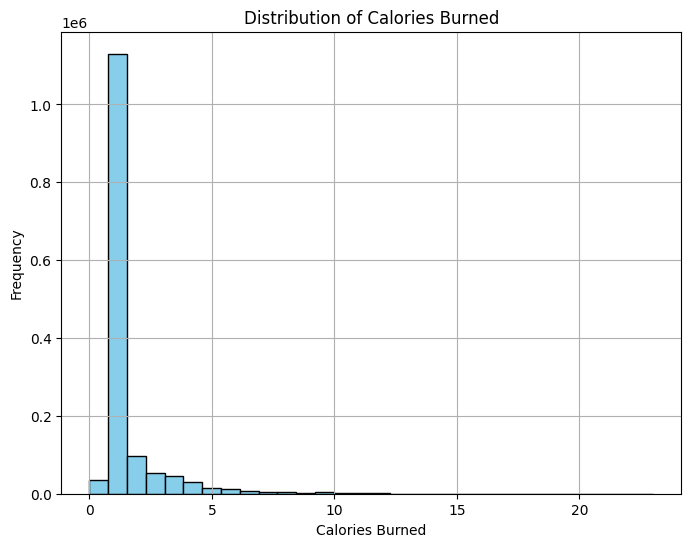

In [ ]:
import matplotlib.pyplot as plt

# Plotting a histogram of 'Calories'
plt.figure(figsize=(8, 6))
plt.hist(model_data['Calories'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Calories Burned')
plt.xlabel('Calories Burned')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

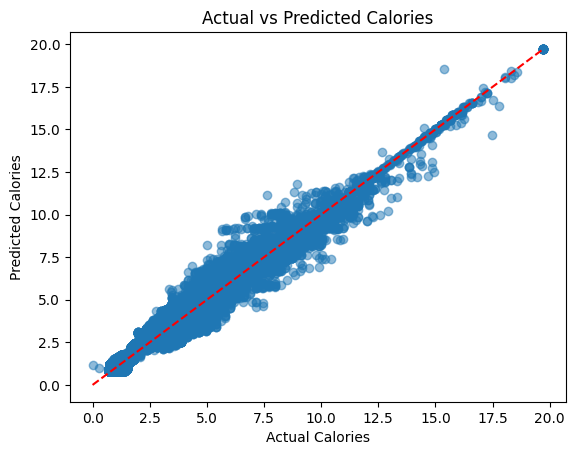

In [ ]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_test)], '--', color='red')  # Identity line
plt.title('Actual vs Predicted Calories')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.show()
#shows that model is accurate even when calorie expenditure is high, success!